<a href="https://colab.research.google.com/github/monikagiemela/drug_repurposing/blob/feature%2Ffrom_google_colab/drug_repurposing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install chembl-webresource-client>=0.10.9

In [ ]:
!pip install rdkit>=2025.9.1

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from chembl_webresource_client.new_client import new_client
from rdkit import Chem
from rdkit.Chem import AllChem, MACCSkeys, rdFingerprintGenerator, DataStructs, Draw
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, matthews_corrcoef, roc_auc_score, confusion_matrix, roc_curve, auc
from imblearn.over_sampling import SMOTE
from tqdm.notebook import tqdm
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
%ls -l '/content/drive/MyDrive/IU/drug_repurposing'

total 2109
-rw------- 1 root root 2154620 Dec 15 18:13 chembl_approved_drugs.csv
-rw------- 1 root root       0 Dec 15 15:29 drug_repurposing
drwx------ 2 root root    4096 Dec 16 13:56 output/


In [ ]:
import os

output_dir = '/content/drive/MyDrive/IU/drug_repurposing/output'

# Create the output directory if it doesn't exist
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"Created directory: {output_dir}")
else:
    print(f"Directory already exists: {output_dir}")


Directory already exists: /content/drive/MyDrive/IU/drug_repurposing/output


Fetch bioactivity data for Human c-Met (CHEMBL3717). We filter for:
- Target: Human c-Met
- Assay Type: Binding (B)
- Standard Type: IC50
- Standard Units: nM
- Standard Relation: '='

In [ ]:
# Definition of Target ID for Human c-Met
target_id = 'CHEMBL3717'
print("Fetching bioactivity data from ChEMBL...")

# Fetch Activity Data
activity = new_client.activity
res = activity.filter(target_chembl_id=target_id).filter(standard_type="IC50")

# Convert to DataFrame
df = pd.DataFrame.from_dict(res)
print(f"Raw data fetched: {df.shape[0]} records")

# Initial Cleanup
# Keeping only relevant columns
cols_to_keep = ['molecule_chembl_id', 'canonical_smiles', 'standard_value', 'standard_units', 'standard_type', 'standard_relation']
df = df[cols_to_keep]

# Filtering
df = df[df['standard_units'] == 'nM']             # Keep only Nanomolar units
df = df[df['standard_relation'] == '=']           # Keep only precise measurements
df = df[df['standard_value'].notna()]             # Remove empty values
df['standard_value'] = df['standard_value'].astype(float)

# Handle Duplicates
# If a drug was tested multiple times, take the median value to limit outliers.
df_clean = df.groupby(['molecule_chembl_id', 'canonical_smiles'])['standard_value'].median().reset_index()

print(f"Cleaned dataset (Unique Compounds): {df_clean.shape[0]}")
df_clean.head()

Fetching bioactivity data from ChEMBL...
Raw data fetched: 8432 records
Cleaned dataset (Unique Compounds): 4165


,molecule_chembl_id,canonical_smiles,standard_value
0,CHEMBL1086675,CCCc1c(C(=O)Nc2ccc(Oc3ccnc4cc(-c5cn(C)cn5)sc34...,70.0
1,CHEMBL1086676,Cn1cnc(-c2cc3nccc(Oc4ccc(NC(=O)c5cnn(-c6ccccc6...,80.0
2,CHEMBL1086932,Cc1c(C(=O)Nc2ccc(Oc3ccnc4cc(-c5cn(C)cn5)sc34)c...,70.0
3,CHEMBL1087650,CN1C[C@@H]2C[C@H]1CN2c1ccc(-c2ccnc3c(-c4cccc(O...,3100.0
4,CHEMBL1087984,COc1cc2nccc(Oc3ccc(NC(=O)c4cnn(-c5ccccc5)c4C(F...,630.0


Define the binary classification threshold:
- Active (1): IC50 <= 1000 nM (1 uM)
- Inactive (0): IC50 > 1000 nM

In [ ]:
threshold_nm = 1000

def categorize_activity(value):
    if value <= threshold_nm:
        return 1
    else:
        return 0

df_clean['activity_label'] = df_clean['standard_value'].apply(categorize_activity)

# # Visualize Class Balance
# sns.countplot(x='activity_label', data=df_clean, palette='viridis')
# plt.title('Class Distribution: Active (1) vs Inactive (0)')
# plt.xlabel('Bioactivity Class')
# plt.ylabel('Count')
# plt.show()

print(df_clean['activity_label'].value_counts())

activity_label
1    3587
0     578
Name: count, dtype: int64


Generate features:
- ECFP4 (Morgan Fingerprints): Radius 2, 1024 bits.
- MACCS Keys: 166 structural keys.

In [ ]:
def calculate_fingerprints(smiles_list):
    ecfp4_list = []
    maccs_list = []
    valid_indices = []

    # Morgan Generator (Radius 2 = ECFP4, 1024 bits)
    mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024)

    print("Generating Fingerprints...")
    for idx, smiles in enumerate(smiles_list):
        try:
            mol = Chem.MolFromSmiles(smiles)
            if mol:
                # Generate ECFP4 as NumPy array
                ecfp4_array = mfpgen.GetFingerprintAsNumPy(mol)

                # Generate MACCS Keys and convert to NumPy array
                maccs_fp = MACCSkeys.GenMACCSKeys(mol)
                maccs_array = np.zeros((0,), dtype=np.int8)
                DataStructs.ConvertToNumpyArray(maccs_fp, maccs_array)

                ecfp4_list.append(ecfp4_array)
                maccs_list.append(maccs_array)
                valid_indices.append(idx)
        except Exception as e:
            print(f"Error while generating fingerprints: {e}")
            continue

    # Return both arrays so they can be stacked later
    return np.array(ecfp4_list), np.array(maccs_list), valid_indices

In [ ]:
X_ecfp4, X_maccs, valid_idx = calculate_fingerprints(df_clean['canonical_smiles'])
y = df_clean['activity_label'].iloc[valid_idx].values

# Fingerprints combined
X = np.hstack((X_ecfp4, X_maccs))

print(f"Final Feature Matrix Shape: {X.shape}")

Generating Fingerprints...
Final Feature Matrix Shape: (4165, 1191)


Data preprocessing
- Split: 80/20 Train-Test.
- SMOTE: Synthetic Minority Over-sampling applied to the training set.

In [ ]:
# Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Appling SMOTE to training data
print("Applying SMOTE to training data...")
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print(f"Resampled Training Shape: {X_train_res.shape}")


Applying SMOTE to training data...
Resampled Training Shape: (5740, 1191)


Visualize class balance before and after SMOTE resampling

1    2870
0     462
Name: count, dtype: int64
1    2870
0    2870
Name: count, dtype: int64


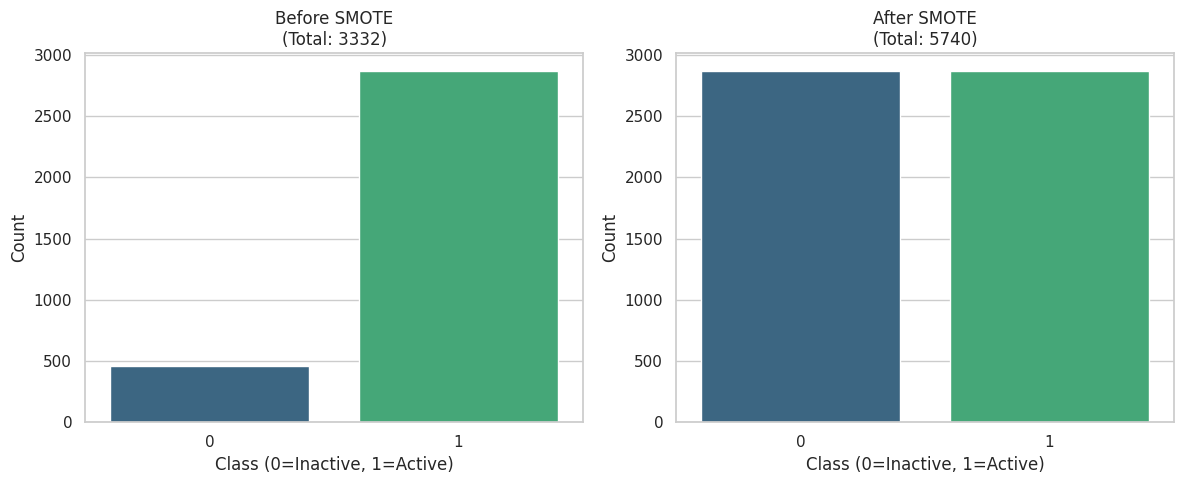

In [ ]:
# 'y_train' is data BEFORE SMOTE, 'y_train_res' is AFTER
original_counts = pd.Series(y_train).value_counts()
resampled_counts = pd.Series(y_train_res).value_counts()
print(original_counts)
print(resampled_counts)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Before SMOTE
sns.barplot(x=original_counts.index, y=original_counts.values, ax=axes[0], palette='viridis')
axes[0].set_title(f"Before SMOTE\n(Total: {len(y_train)})")
axes[0].set_xlabel("Class (0=Inactive, 1=Active)")
axes[0].set_ylabel("Count")

# Plot 2: After SMOTE
sns.barplot(x=resampled_counts.index, y=resampled_counts.values, ax=axes[1], palette='viridis')
axes[1].set_title(f"After SMOTE\n(Total: {len(y_train_res)})")
axes[1].set_xlabel("Class (0=Inactive, 1=Active)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

Optimizing Random Forest...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Params for Random Forest: {'max_depth': 30, 'min_samples_split': 2, 'n_estimators': 200}
Optimizing SVM...
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Best Params for SVM: {'C': 10, 'kernel': 'rbf'}
Optimizing XGBoost...
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best Params for XGBoost: {'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 200}


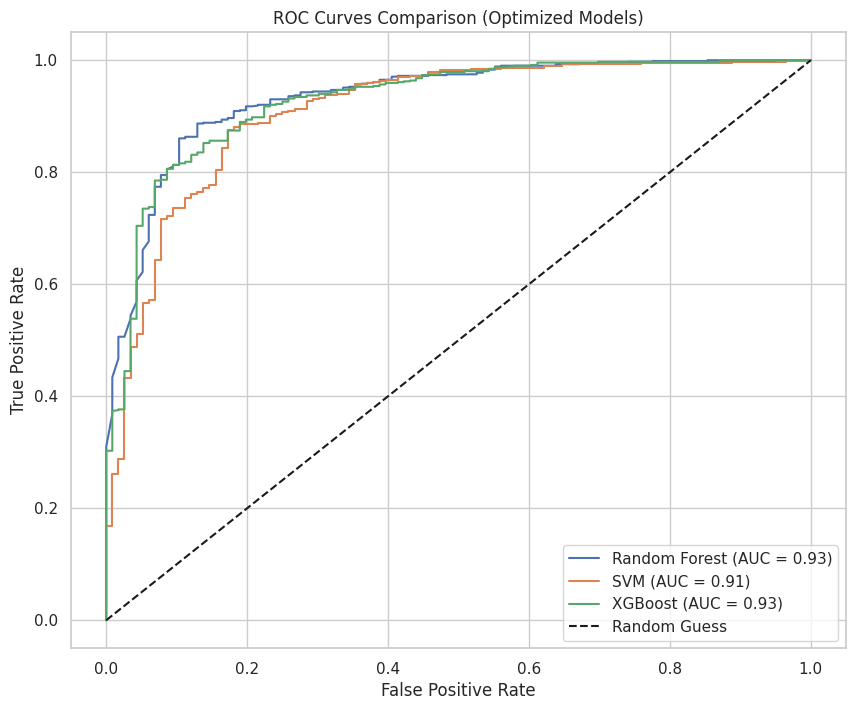

               Accuracy  F1-Score       MCC   ROC-AUC
Random Forest  0.911164  0.948682  0.618928  0.933800
SVM            0.913565  0.950276  0.621935  0.909717
XGBoost        0.908764  0.947514  0.600779  0.927482
Model performance metrics saved.


In [ ]:
# Parameter for GridSearch
param_grids = {
    'Random Forest': {
        'model': RandomForestClassifier(random_state=42, n_jobs=-1),
        'params': {
            'n_estimators': [100, 200],
            'max_depth': [None, 20, 30],
            'min_samples_split': [2, 5]
        }
    },
    'SVM': {
        'model': SVC(probability=True, random_state=42),
        'params': {
            'C': [0.1, 1, 10],
            'kernel': ['rbf']
        }
    },
    'XGBoost': {
        'model': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, n_jobs=-1),
        'params': {
            'n_estimators': [100, 200, 500],
            'learning_rate': [0.01, 0.1, 0.3],
            'max_depth': [3, 6, 10]
        }
    }
}

# Train and evaluate loop with GridSearch
results = {}
best_models = {}

plt.figure(figsize=(10, 8))

for name, config in param_grids.items():
    print(f"Optimizing {name}...")

    cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # Initialize GridSearch
    grid_search = GridSearchCV(
        estimator=config['model'],
        param_grid=config['params'],
        cv=cv_strategy,
        scoring='f1',
        n_jobs=-1,
        verbose=1
    )

    # Fit the GridSearch
    grid_search.fit(X_train_res, y_train_res)

    # Get the best model
    best_model = grid_search.best_estimator_
    best_models[name] = best_model

    print(f"Best Params for {name}: {grid_search.best_params_}")

    # Evaluate on test set (unseen data)
    y_pred = best_model.predict(X_test)
    y_prob = best_model.predict_proba(X_test)[:, 1]

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    mcc = matthews_corrcoef(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    results[name] = {'Accuracy': acc, 'F1-Score': f1, 'MCC': mcc, 'ROC-AUC': roc_auc}

    # Plot ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison (Optimized Models)')
plt.legend()
plt.show()

# Display results in a table
results_df = pd.DataFrame(results).T
print(results_df)
# Save model evaluation results table
results_df.to_csv(os.path.join(output_dir, 'model_performance_metrics.csv'), index=True)
print("Model performance metrics saved.")

In [ ]:
# Recreate and save ROC curves (from GridSearch results)
plt.figure(figsize=(10, 8))
for name, config in param_grids.items():
    roc_auc = results[name]['ROC-AUC']
    fpr, tpr, _ = roc_curve(y_test, best_models[name].predict_proba(X_test)[:, 1])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison (Optimized Models)')
plt.legend()
plt.savefig(os.path.join(output_dir, 'roc_curves_optimized.png'))
print("ROC curves plot saved.")
plt.close()


ROC curves plot saved.


Model training
- Models: Random Forest, SVM, XGBoost.

Training Random Forest...
Training SVM...
Training XGBoost...


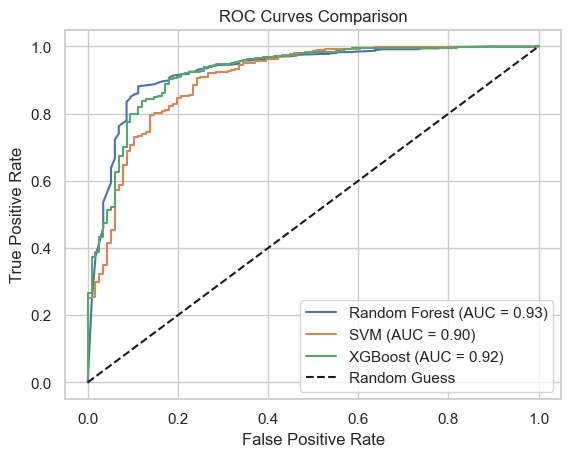

               Accuracy  F1-Score       MCC   ROC-AUC
Random Forest  0.908764  0.947075  0.616676  0.928474
SVM            0.909964  0.948169  0.607332  0.903165
XGBoost        0.915966  0.951524  0.637182  0.923075


In [ ]:
# Initialize Models
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'SVM': SVC(probability=True, random_state=42),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, n_jobs=-1)
}

# Train and Evaluate Loop
results = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_res, y_train_res)

    # Predictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    mcc = matthews_corrcoef(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    results[name] = {'Accuracy': acc, 'F1-Score': f1, 'MCC': mcc, 'ROC-AUC': roc_auc}

    # Plot ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend()
plt.show()

# Display Results Table
results_df = pd.DataFrame(results).T
print(results_df)

Application of the best model to screen the Approved Drugs list.

In [ ]:
import pandas as pd

# Load approved drugs
approved_df = pd.read_csv('/content/drive/MyDrive/IU/drug_repurposing/chembl_approved_drugs.csv', sep=';')
screen_df = pd.DataFrame(approved_df)
screen_df = screen_df[screen_df["Smiles"].notna()] # Remove NaNs
print(screen_df.shape)

# Calculate fingerprints for screening library
print("Featurizing Screening Library...")
X_screen_ecfp, X_screen_maccs, valid_screen_idx = calculate_fingerprints(screen_df['Smiles'])
X_screen = np.hstack((X_screen_ecfp, X_screen_maccs))

# Ensure 'Smiles' column is string type and handle potential NaNs
screen_df['Smiles'] = screen_df['Smiles'].astype(str)

# Predict with best model
best_model = best_models['XGBoost']
probs = best_model.predict_proba(X_screen)[:, 1]

# Add predictions to dataFrame
screen_df = screen_df.iloc[valid_screen_idx].copy()
screen_df['Prob_Active'] = probs
# screen_df.shape
display(screen_df)

# Sort by probability (highest first)
top_candidates = screen_df.sort_values(by='Prob_Active', ascending=False).head(10)
top_candidates[['Parent Molecule', 'Name', 'Prob_Active']]

(2038, 31)
Featurizing Screening Library...
Generating Fingerprints...


[21:54:33] WARNING: not removing hydrogen atom without neighbors
[21:54:33] WARNING: not removing hydrogen atom without neighbors
[21:54:33] WARNING: not removing hydrogen atom without neighbors
[21:54:33] WARNING: not removing hydrogen atom without neighbors


,Parent Molecule,Name,Synonyms,Research Codes,Phase,Drug Applicants,USAN Stem,USAN Year,USAN Definition,USAN Stem - Substem,...,Oral,Parenteral,Topical,Black Box,Availability Type,Smiles,Inchi,Withdrawn Flag,Orphan,Prob_Active
0,CHEMBL1200368,BENTIROMIDE,"BENTIROMIDA|BENTIROMIDE|BTPABA PFT|BTPABA, PFT...","BTPABA PFT|BTPABA, PFT|BTPABA-PFT|BTPABAPFT|E-...",4.0,Savage Laboratories Inc Div Altana Inc,'-tirom-',1979.0,"antihyperlipidemic, thyromimetic derivatives",'-tirom-(-tirom-)',...,1,0,0,0,Discontinued,O=C(O)c1ccc(NC(=O)[C@H](Cc2ccc(O)cc2)NC(=O)c2c...,InChI=1S/C23H20N2O5/c26-19-12-6-15(7-13-19)14-...,False,0,0.023784
7,CHEMBL1201261,TYROPANOIC ACID,TYROPANIC ACID|TYROPANOIC ACID,NaN,4.0,Ge Healthcare,NaN,1962.0,NaN,NaN,...,1,0,0,0,Discontinued,CCCC(=O)Nc1c(I)cc(I)c(CC(CC)C(=O)O)c1I,InChI=1S/C15H18I3NO3/c1-3-5-12(20)19-14-11(17)...,False,0,0.005274
11,CHEMBL2105248,POTASSIUM BITARTRATE,ACID POTASSIUM TARTRATE|E-336(I)|FAECLA|FAECUL...,E-336(I)|INS NO.336(I)|INS-336(I)|NSC-155080,4.0,Evofem Inc,NaN,1988.0,NaN,NaN,...,0,0,1,0,Prescription Only,O=C([O-])[C@H](O)[C@@H](O)C(=O)O.[K+],"InChI=1S/C4H6O6.K/c5-1(3(7)8)2(6)4(9)10;/h1-2,...",False,0,0.000778
14,CHEMBL1165268,IODIPAMIDE,ADIPIODONA|ADIPIODONE|CHOLOGRAFIN|IODIPAMIDE|N...,NSC-757423,4.0,Bracco Diagnostics Inc,'io-; -pamide',1963.0,iodine-containing contrast media; diuretics (s...,'io-(io-); -pamide(-pamide)',...,0,1,1,0,Discontinued,O=C(CCCCC(=O)Nc1c(I)cc(I)c(C(=O)O)c1I)Nc1c(I)c...,InChI=1S/C20H14I6N2O6/c21-7-5-9(23)17(15(25)13...,False,0,0.000885
17,CHEMBL867,IOPANOIC ACID,ACIDE IOPANOIQUE|ACIDO IOPANOICO|ACIDUM IOPANO...,NSC-41706,4.0,Ge Healthcare,'io-',NaN,iodine-containing contrast media,'io-(io-)',...,1,0,0,0,Discontinued,CCC(Cc1c(I)cc(I)c(N)c1I)C(=O)O,InChI=1S/C11H12I3NO2/c1-2-5(11(16)17)3-6-7(12)...,False,0,0.000578
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2724,CHEMBL12713,SERTINDOLE,LU 23-174|LU-23-174|SERDOLECT|SERLECT|SERTINDO...,LU 23-174|LU-23-174,4.0,NaN,NaN,1992.0,NaN,NaN,...,1,0,0,0,Withdrawn,O=C1NCCN1CCN1CCC(c2cn(-c3ccc(F)cc3)c3ccc(Cl)cc...,InChI=1S/C24H26ClFN4O/c25-18-1-6-23-21(15-18)2...,True,0,0.921104
2726,CHEMBL3707348,ACALABRUTINIB,ACALABRUTINIB|ACP-196,ACP-196,4.0,Astrazeneca Uk Ltd,'-tinib',2016.0,tyrosine kinase inhibitors: tyrosine kinase in...,'-tinib(-tinib (-brutinib))',...,1,0,0,0,Prescription Only,CC#CC(=O)N1CCC[C@H]1c1nc(-c2ccc(C(=O)Nc3ccccn3...,InChI=1S/C26H23N7O2/c1-2-6-21(34)32-15-5-7-19(...,False,0,0.030938
2729,CHEMBL2105755,NALDEMEDINE,NALDEMEDINA|NALDEMEDINE|Naldemedine|S-297995,S-297995,4.0,Biodelivery Sciences International Inc,'nal-',2011.0,narcotic agonists/antagonists (normorphine type),'nal-(nal-)',...,1,0,0,0,Prescription Only,CC(C)(NC(=O)C1=C(O)[C@@H]2Oc3c(O)ccc4c3[C@@]23...,"InChI=1S/C32H34N4O6/c1-30(2,29-33-27(35-42-29)...",False,0,0.969037
2730,CHEMBL4303060,MELPHALAN FLUFENAMIDE,J 1 (PRODRUG)|J-1|J-1 (PRODRUG)|J1|J1 (PRODRUG...,J 1 (PRODRUG)|J-1|J-1 (PRODRUG)|J1|J1 (PRODRUG...,4.0,NaN,'-',2020.0,-,'-(-)',...,0,1,0,0,Withdrawn,CCOC(=O)[C@H](Cc1ccc(F)cc1)NC(=O)[C@@H](N)Cc1c...,InChI=1S/C24H30Cl2FN3O3/c1-2-33-24(32)22(16-18...,True,0,0.046165


,Parent Molecule,Name,Prob_Active
2427,CHEMBL3188267,CAPMATINIB,0.998631
2430,CHEMBL1183349,ISAVUCONAZONIUM,0.998402
1605,CHEMBL1201204,CEFPIRAMIDE,0.998283
1076,CHEMBL4113131,ENSARTINIB,0.998134
2088,CHEMBL2105717,CABOZANTINIB,0.997873
568,CHEMBL1251,GANIRELIX,0.997625
1103,CHEMBL3948730,UMBRALISIB,0.997237
2696,CHEMBL4594438,LENACAPAVIR,0.997180
850,CHEMBL398435,TICAGRELOR,0.997085
1803,CHEMBL2403238,CABOTEGRAVIR,0.996677


Tanimoto Similarity Analysis
Validate the top hits by checking their similarity to a known inhibitors (Crizotinib, Capmatinib).

In [ ]:
# Define Reference Molecule (Crizotinib, Capmatinib)
ref_drugs = {
    "Crizotinib": "C[C@H](C1=C(C=CC(=C1Cl)F)Cl)OC2=C(N=CC(=C2)C3=CN(N=C3)C4CCNCC4)N",
    "Capmatinib": "CNC(=O)C1=C(C=C(C=C1)C2=NN3C(=CN=C3N=C2)CC4=CC5=C(C=C4)N=CC=C5)F"
}
# Morgan Generator (Radius 2 = ECFP4, 1024 bits)
mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024)
ref_fps = {}
for name, ref_smile in ref_drugs.items():
    ref_mol = Chem.MolFromSmiles(ref_smile)
    if ref_mol:
        ref_fps[name] = mfpgen.GetFingerprint(ref_mol)

def calculate_max_tanimoto(candidate_smiles):
    try:
        cand_mol = Chem.MolFromSmiles(candidate_smiles)
        if not cand_mol: return 0.0, "None"
        cand_fp = mfpgen.GetFingerprint(cand_mol)
        max_sim, best_match = 0.0, "None"
        for ref_name, ref_fp in ref_fps.items():
            sim = DataStructs.TanimotoSimilarity(ref_fp, cand_fp)
            if sim > max_sim:
                max_sim = sim
                best_match = ref_name
        return max_sim, best_match
    except Exception as e:
        return 0.0, f"Error: {e}"

# Apply to Top Candidates
top_candidates[['Max_Similarity', "Most_Similar_To"]] = top_candidates['Smiles'].apply(lambda x: pd.Series(calculate_max_tanimoto(x)))

# Interpretation
def interpret_similarity(score):
    if score > 0.4:
        return "High (Known Scaffold)"
    else:
        return "Low (Novel/Repurposing)"

top_candidates['Interpretation'] = top_candidates['Max_Similarity'].apply(interpret_similarity)

# Save top candidates table
top_candidates[['Name', 'Prob_Active', 'Max_Similarity', 'Most_Similar_To', 'Interpretation']].to_csv(os.path.join(output_dir, 'top_drug_candidates.csv'), index=False)
print("Top drug candidates saved.")

top_candidates[['Name', 'Prob_Active', 'Max_Similarity', 'Most_Similar_To', 'Interpretation']]

Top drug candidates saved.


,Name,Prob_Active,Max_Similarity,Most_Similar_To,Interpretation
2427,CAPMATINIB,0.998631,1.000000,Capmatinib,High (Known Scaffold)
2430,ISAVUCONAZONIUM,0.998402,0.217054,Capmatinib,Low (Novel/Repurposing)
1605,CEFPIRAMIDE,0.998283,0.132231,Capmatinib,Low (Novel/Repurposing)
1076,ENSARTINIB,0.998134,0.415730,Crizotinib,High (Known Scaffold)
2088,CABOZANTINIB,0.997873,0.195652,Capmatinib,Low (Novel/Repurposing)
568,GANIRELIX,0.997625,0.169014,Capmatinib,Low (Novel/Repurposing)
1103,UMBRALISIB,0.997237,0.207547,Crizotinib,Low (Novel/Repurposing)
2696,LENACAPAVIR,0.997180,0.144928,Crizotinib,Low (Novel/Repurposing)
850,TICAGRELOR,0.997085,0.141593,Capmatinib,Low (Novel/Repurposing)
1803,CABOTEGRAVIR,0.996677,0.170000,Capmatinib,Low (Novel/Repurposing)


Molecule grid image saved.


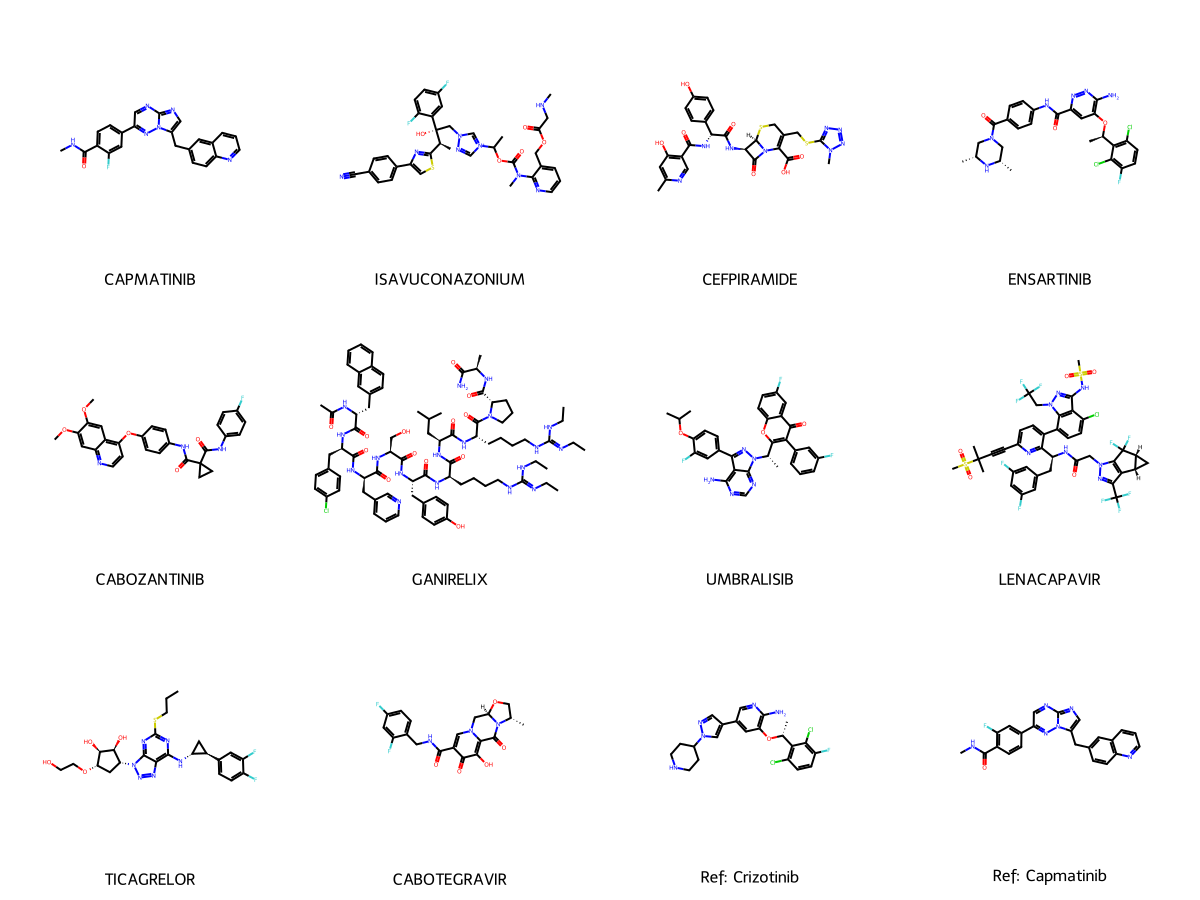

In [ ]:
# Get the top candidates
top3_smiles = top_candidates['Smiles'].tolist()
top3_names = top_candidates['Name'].tolist()

# Add reference drugs for comparison
plot_smiles = top3_smiles + [ref_drugs['Crizotinib'], ref_drugs['Capmatinib']]
plot_names = top3_names + ['Ref: Crizotinib', 'Ref: Capmatinib']

# Create molecule objects
mols = [Chem.MolFromSmiles(s) for s in plot_smiles]

# Draw them in a grid
img = Draw.MolsToGridImage(
    mols,
    molsPerRow=4,
    subImgSize=(300, 300),
    legends=plot_names,
    returnPNG=False
)

# Display
img.save(os.path.join(output_dir, 'top_molecules_grid.png'))
print("Molecule grid image saved.")
img